In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, random_split
import numpy as np
import matplotlib.pyplot as plt
import os
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from sklearn.metrics import roc_auc_score
from torchsummary import summary
from tqdm import tqdm
import sys

sys.path.insert(0,'..')

In [35]:
data_dir = os.path.join('dataset','train')

View Individual Images

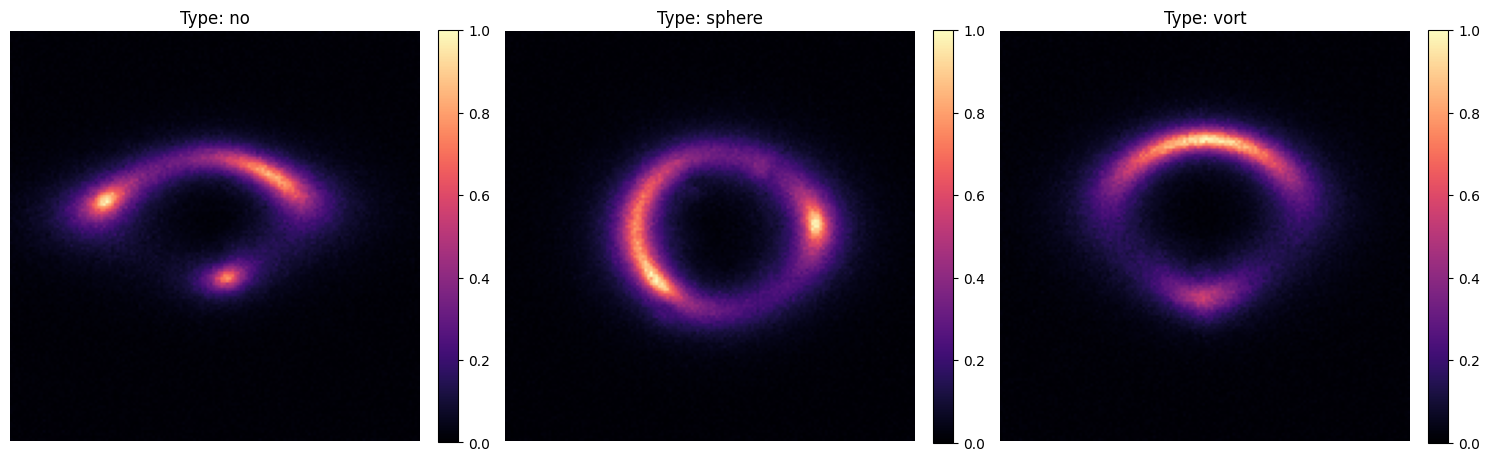

In [36]:

classes = ['no','sphere','vort']
fig, axes = plt.subplots(1,3, figsize=(15,5))

for i,cl in enumerate(classes):
    class_path = os.path.join(data_dir,cl)
    file_name = [f for f in os.listdir(class_path) if f.endswith('.npy')][0]
    img_array = np.load(os.path.join(class_path,file_name))
    
    im=axes[i].imshow(img_array.squeeze(),cmap='magma')
    axes[i].set_title(f"Type: {cl}")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    
plt.tight_layout()
plt.show()

Transforms

In [37]:
transform_norm=transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

Custom Dataset Class for preparing data

In [38]:
class LensingNpyDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir=root_dir
        self.transform=transform
        self.data=[]
        self.classes=sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        for idx, cl in enumerate(self.classes):
            class_path =os.path.join(root_dir, cl)
            if not os.path.isdir(class_path):
                continue
            for f in os.listdir(class_path):
                if f.endswith('.npy'):
                    self.data.append((os.path.join(class_path,f), idx))
                    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        #Load image and ensure its float32 for PyTorch compatibility
        image = np.load(img_path).astype(np.float32)
        #Handle the shape 
        if image.shape[0] == 1:
            image = image.squeeze(0)
        
        #Convert to torch tensor    
        image=torch.from_numpy(image).unsqueeze(0)
        
        #Normalization
        if self.transform:
            image=self.transform(image)
            
        return image, label
                

In [39]:
dataset=LensingNpyDataset(root_dir=data_dir, transform=transform_norm)

train_size=int(0.9*len(dataset))
val_size=len(dataset)-train_size
train_data, val_data=random_split(dataset,[train_size, val_size])

  0%|          | 0/27000 [00:00<?, ?it/s]

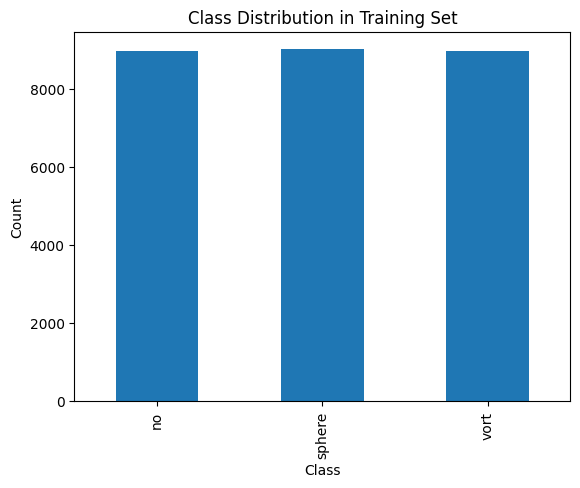

  0%|          | 0/3000 [00:00<?, ?it/s]

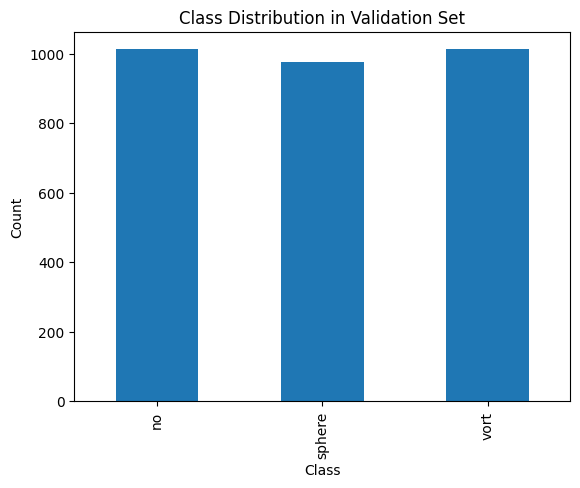

In [21]:
sys.path.insert(0,'..')
from training import class_counts

class_counts(train_data).plot(kind='bar', title='Class Distribution in Training Set', xlabel='Class', ylabel='Count')
plt.show()

class_counts(val_data).plot(kind='bar', title='Class Distribution in Validation Set', xlabel='Class', ylabel='Count')
plt.show()

In [40]:
train_loader=DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader=DataLoader(val_data, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Checking shapes of data and labels

In [41]:
images, labels=next(iter(train_loader))
print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")

Batch of images shape: torch.Size([32, 1, 150, 150])
Batch of labels shape: torch.Size([32])


Using ResNet50 architecture. I am changing the first and last layer of the ResNet50 network for this task.

In [42]:
model=models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [43]:
# Freeze early layers but keep later layers trainable for fine-tuning
for param in model.layer1.parameters():
    param.requires_grad = False
    
for param in model.layer2.parameters():
    param.requires_grad = False
    
# Allow layer3 and layer4 to train (fine-tune)
for param in model.layer3.parameters():
    param.requires_grad = True
    
for param in model.layer4.parameters():
    param.requires_grad = True

In [44]:
model.conv1

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

In [45]:
in_features=model.fc.in_features

model.conv1=nn.Conv2d(1,64, kernel_size=7, stride =2, padding=3, bias=False)

final_layer=nn.Sequential()

final_layer.append(nn.Linear(in_features, 256))
final_layer.append(nn.ReLU())
final_layer.append(nn.Dropout(0.5))
final_layer.append(nn.Linear(256, 3))

model.fc=final_layer
print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [46]:
# Use different learning rates for different parts of the network
params_to_update = []

# Lower learning rate for earlier layers
params_to_update.append({'params': model.conv1.parameters(), 'lr': 0.00005})
params_to_update.append({'params': model.layer1.parameters(), 'lr': 0.000005})
params_to_update.append({'params': model.layer2.parameters(), 'lr': 0.000005})

# Higher learning rate for later layers and head
params_to_update.append({'params': model.layer3.parameters(), 'lr': 0.00005})
params_to_update.append({'params': model.layer4.parameters(), 'lr': 0.00005})
params_to_update.append({'params': model.fc.parameters(), 'lr': 0.0005})

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(params_to_update, weight_decay=1e-4)

print("loss function:", loss_fn)
print("optimizer:", optimizer)
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

loss function: CrossEntropyLoss()
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 5e-05
    maximize: False
    weight_decay: 0.0001

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 5e-06
    maximize: False
    weight_decay: 0.0001

Parameter Group 2
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 5e-06
    maximize: False
    weight_decay: 0.0001

Parameter Group 3
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 5e-05
    maximize: False
    weight_decay: 0.0001

Parameter Group 4
    amsgrad: False
    betas: (0.9, 0.999)
    capturable:

In [47]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cuda device.


In [48]:
model.to(device)
summary(model, input_size=(1, 150, 150), batch_size=32)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [32, 64, 75, 75]           3,136
       BatchNorm2d-2           [32, 64, 75, 75]             128
              ReLU-3           [32, 64, 75, 75]               0
         MaxPool2d-4           [32, 64, 38, 38]               0
            Conv2d-5           [32, 64, 38, 38]           4,096
       BatchNorm2d-6           [32, 64, 38, 38]             128
              ReLU-7           [32, 64, 38, 38]               0
            Conv2d-8           [32, 64, 38, 38]          36,864
       BatchNorm2d-9           [32, 64, 38, 38]             128
             ReLU-10           [32, 64, 38, 38]               0
           Conv2d-11          [32, 256, 38, 38]          16,384
      BatchNorm2d-12          [32, 256, 38, 38]             512
           Conv2d-13          [32, 256, 38, 38]          16,384
      BatchNorm2d-14          [32, 256,

In [49]:
# Verify trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

# Breakdown by layer
print("\nTrainable layers:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.numel():,}")


Total parameters: 24,027,075
Trainable parameters: 22,591,683
Frozen parameters: 1,435,392

Trainable layers:
  conv1.weight: 3,136
  bn1.weight: 64
  bn1.bias: 64
  layer3.0.conv1.weight: 131,072
  layer3.0.bn1.weight: 256
  layer3.0.bn1.bias: 256
  layer3.0.conv2.weight: 589,824
  layer3.0.bn2.weight: 256
  layer3.0.bn2.bias: 256
  layer3.0.conv3.weight: 262,144
  layer3.0.bn3.weight: 1,024
  layer3.0.bn3.bias: 1,024
  layer3.0.downsample.0.weight: 524,288
  layer3.0.downsample.1.weight: 1,024
  layer3.0.downsample.1.bias: 1,024
  layer3.1.conv1.weight: 262,144
  layer3.1.bn1.weight: 256
  layer3.1.bn1.bias: 256
  layer3.1.conv2.weight: 589,824
  layer3.1.bn2.weight: 256
  layer3.1.bn2.bias: 256
  layer3.1.conv3.weight: 262,144
  layer3.1.bn3.weight: 1,024
  layer3.1.bn3.bias: 1,024
  layer3.2.conv1.weight: 262,144
  layer3.2.bn1.weight: 256
  layer3.2.bn1.bias: 256
  layer3.2.conv2.weight: 589,824
  layer3.2.bn2.weight: 256
  layer3.2.bn2.bias: 256
  layer3.2.conv3.weight: 262,144
 

In [50]:
from training import train
train?

Signature:
train(
    model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    epochs=20,
    device='cpu',
    scheduler=None,
    checkpoint_path=None,
    early_stopping=False,
)
Docstring: <no docstring>
File:      ~/ai_projects/gsoc_deeplense/training.py
Type:      function

In [51]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

/home/rwitobaansheikh/ai_projects/.venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [52]:
train_losses, val_losses, train_accuracies, val_accuracies, train_aucs, val_aucs = train(
    model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    epochs=150,
    device=device,
    scheduler=scheduler,
    checkpoint_path="model/best_model.pth",
    early_stopping=True
)

Model evaluation before start of training...


Scoring:   0%|          | 0/844 [00:00<?, ?it/s]

Scoring:   0%|          | 0/94 [00:00<?, ?it/s]



Starting epoch 1/150


Training:   0%|          | 0/844 [00:00<?, ?it/s]

...

Epoch: 119
Training loss: 0.2058
Training accuracy: 92.0667%
Training AUC: 0.9864
Validation loss: 0.2892
Validation accuracy: 88.7000%
Validation AUC: 0.9750


Starting epoch 120/150


Training:   0%|          | 0/844 [00:00<?, ?it/s]

Scoring:   0%|          | 0/844 [00:00<?, ?it/s]

Scoring:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch: 120
Training loss: 0.2124
Training accuracy: 91.7815%
Training AUC: 0.9856
Validation loss: 0.2768
Validation accuracy: 89.5000%
Validation AUC: 0.9766
Early stopping triggered after 120 epochs


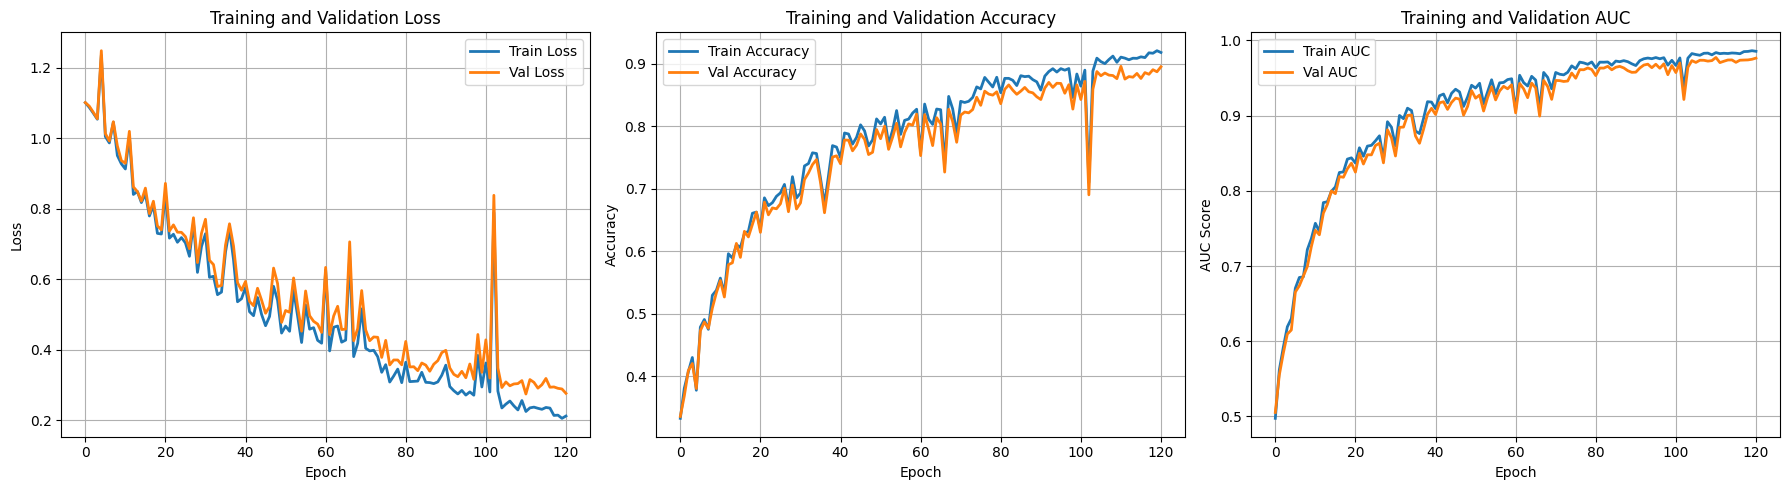

Final Training Accuracy: 0.9178
Final Validation Accuracy: 0.8950
Final Training AUC: 0.9856
Final Validation AUC: 0.9766


In [55]:
# Plot training results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accuracies, label='Train Accuracy', linewidth=2)
axes[1].plot(val_accuracies, label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

# AUC plot
axes[2].plot(train_aucs, label='Train AUC', linewidth=2)
axes[2].plot(val_aucs, label='Val AUC', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC Score')
axes[2].set_title('Training and Validation AUC')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {train_accuracies[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Final Training AUC: {train_aucs[-1]:.4f}")
print(f"Final Validation AUC: {val_aucs[-1]:.4f}")


In [57]:
CHECKPOINT_PATH = "model/best_model.pth"
CLASSES = ['no', 'sphere', 'vort']

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [58]:
import json

# 1. Define the Save Directory
save_dir = "DeepLense_Gravitational_Lensing_Results"
os.makedirs(save_dir, exist_ok=True)

# 2. Save the Model Weights
model_path = os.path.join(save_dir, "resnet50_lensing_final.pth")
torch.save(model.state_dict(), model_path)

# This handles both raw datasets and Subset objects
try:
    mapping = train_data.dataset.class_to_idx
except AttributeError:
    mapping = train_data.dataset.dataset.class_to_idx

with open(os.path.join(save_dir, "class_mapping.json"), "w") as f:
    json.dump(mapping, f)

# 4. Save Training History for Plots
history = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_aucs": train_aucs,
    "val_aucs": val_aucs,
    "train_accuracies": train_accuracies,
    "val_accuracies": val_accuracies
}
with open(os.path.join(save_dir, "training_history.json"), "w") as f:
    json.dump(history, f)

print(f"Task 1 Artifacts saved to '{save_dir}'")
print(f"Final Validation AUC: {val_aucs[-1]:.4f}")

Task 1 Artifacts saved to 'DeepLense_Gravitational_Lensing_Results'
Final Validation AUC: 0.9766


In [59]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_final_roc(model, dataloader, device, classes, title_suffix=""):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Binarize labels for multiclass ROC
    n_classes = len(classes)
    y_test = label_binarize(all_labels, classes=range(n_classes))
    
    plt.figure(figsize=(8, 6))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multiclass ROC Curve - {title_suffix}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

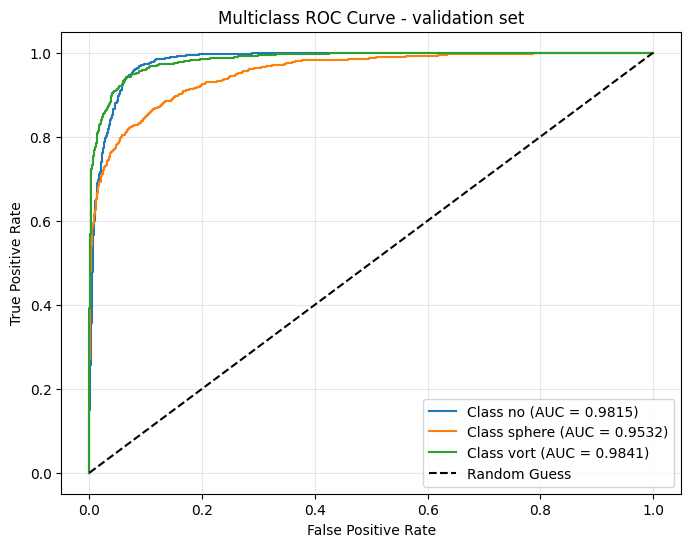

In [60]:
plot_final_roc(model, val_loader, device, ['no', 'sphere', 'vort'], "validation set")

Evaluating trained Model on Test Set

In [66]:
transform_eval = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [67]:
test_dir= os.path.join('dataset','val')
test_dataset=LensingNpyDataset(root_dir=test_dir, transform=transform_eval)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)

In [68]:
from training import predict
predict?

Signature: predict(model, data_loader, device='cpu')
Docstring: <no docstring>
File:      ~/ai_projects/gsoc_deeplense/training.py
Type:      function

In [69]:
probabilities=predict(model, test_loader, device)
predictions=torch.argmax(probabilities,dim=1)

Predicting:   0%|          | 0/235 [00:00<?, ?it/s]

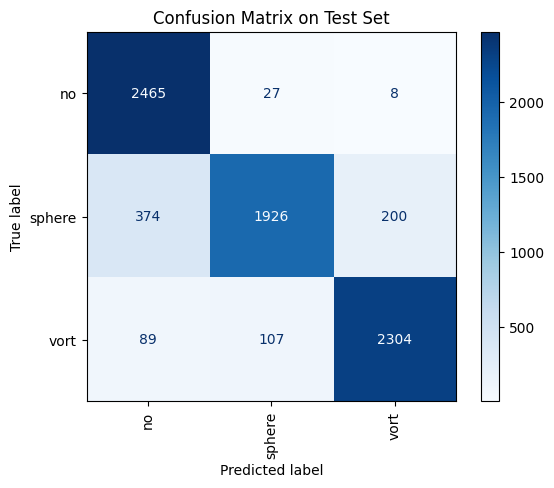

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

targets=[]

for _, labels in test_loader:
    targets.extend(labels.cpu().numpy())
    
cm=confusion_matrix(targets, predictions.cpu().numpy())
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'sphere', 'vort'])
disp.plot(cmap='Blues', xticks_rotation="vertical")
plt.title("Confusion Matrix on Test Set")
plt.show()

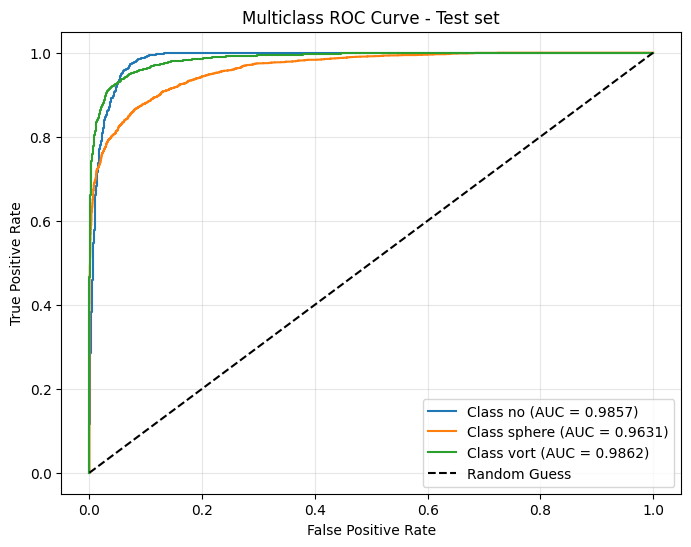

In [71]:
plot_final_roc(model, test_loader, device, ['no', 'sphere', 'vort'], "Test set")